In [1]:
%run -i '../../DL Vorlesung/Preamble.py'
import numpy as np
import pandas as pd
import json
from score_calculator import score_from_mark, EVENT_TO_DISCIPLINE


In [5]:
iaaf_points = pd.read_json('IAAF_2025.json')
iaaf_points

,gender,event,mark,points
0,men,TJ,19.19,1400
1,men,TJ,19.18,1399
2,men,TJ,19.17,1398
3,men,TJ,19.16,1397
4,men,TJ,19.15,1396
...,...,...,...,...
209363,women,Road Mile,559.28,5
209364,women,Road Mile,561.47,4
209365,women,Road Mile,563.95,3
209366,women,Road Mile,566.89,2


In [14]:
iaaf_points.to_csv("IAAF_2025.csv", index=False)

In [2]:
iaaf_coefficients = pd.read_json('IAAF_Coefficients_2025.json')
iaaf_coefficients

,men,women
TJ,"[0.46036660240304106, 90.96978768056579, -514....","[0.429664588735079, 90.3430418780863, -231.667..."
Road 20kmW,"[2.7350415738593935e-05, -0.6235597178336151, ...","[1.8699883727579893e-05, -0.49365864784227403,..."
Road HM,"[9.469710951061015e-05, -1.352189290133111, 48...","[2.5960366893742383e-05, -0.5606107770831621, ..."
Hept. sh,"[1.751105293982873e-06, 0.186329997981276, -46...",NaN
5000m,"[0.002777997945427, -8.000608112196687, 5760.4...","[0.0008079992470730325, -3.3935897885437782, 3..."
...,...,...
2 Miles sh,"[0.0072099691875840005, -13.078823619347986, 5...","[0.002201991729905, -5.708869030298274, 3700.1..."
Road Mile,"[0.035099677603458, -29.132456259137143, 6044....","[0.011649998601839, -13.513881163102496, 3918...."
Hept.,NaN,"[1.58060718119155e-06, 0.17704089212065202, -4..."
Pent. sh,NaN,"[2.9452123778365277e-06, 0.24163567137421502, ..."


In [4]:
iaaf_points['event'].unique()

array(['TJ', 'Road 20kmW', 'Road HM', 'Hept. sh', '5000m', '300m', '200m',
       '55mH', '60mH', '4x400m', '50mH', '400m', 'Mile sh', '600m',
       '10000m', '20,000mW', '3000m sh', '800m sh', 'Road 3kmW', '5000mW',
       '4x200m sh', '50m', '500m', '15,000mW', 'Road 10 Miles', '100m',
       '4x100m', 'Road 15 km', '500m sh', '110mH', '10,000mW', '35,000mW',
       'Road 100 km', '400mH', 'HJ', '300m sh', '4x400mix', 'Road 30kmW',
       '2 Miles', '2000m SC', 'PV', '400m sh', 'HT', '3000m SC',
       '30,000mW', '1500m', '4x400mix sh', 'JT', 'Road 50kmW',
       'Road 30 km', '55m', '4x200m', '1500m sh', '3000m', 'LJ',
       'Road 5kmW', 'Road 5 km', '3000mW', 'Road 15kmW', '50,000mW',
       '60m', '1000m sh', 'Road 35kmW', '800m', '1000m', 'Road 10kmW',
       'DT', '4x400m sh', 'Dec.', 'Road 20 km', '200m sh',
       'Road Marathon', '2000m', '5000m sh', 'Mile', '2000m sh', 'SP',
       'Road 10 km', 'Road 25 km', '600m sh', '2 Miles sh', 'Road Mile',
       'Hept.', 'Pent. sh

Text(0.5, 0.98, 'Difference between calculated and official IAAF points for all events')

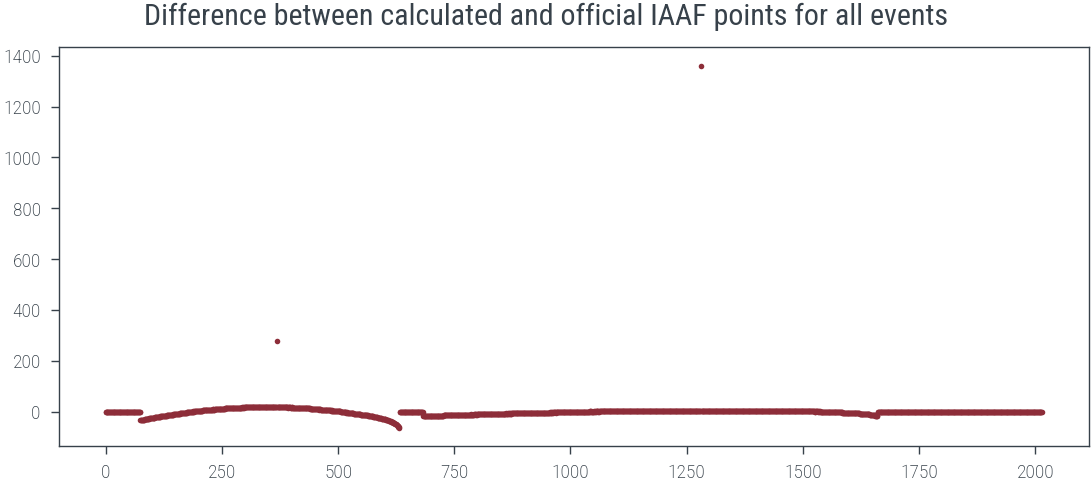

In [33]:
fig, ax = plt.subplots()

difference = []

for _, row in iaaf_points.iterrows():
    mark = row['mark']
    official_score = row['points']
    gender = row['gender']
    event = row['event']
    calculated_score = score_from_mark(gender, event, mark, iaaf_coefficients)
    if abs(official_score - calculated_score) > 0:
        # print(f"Large difference for {gender} {event} {mark}: official {official_score}, calculated {calculated_score}")
        difference.append(calculated_score - official_score)

ax.plot(difference, '.', color=rgb.tue_red, ms=2)
fig.suptitle("Difference between calculated and official IAAF points for all events")

Text(0.5, 0.98, "Calculated IAAF points for men's 100m")

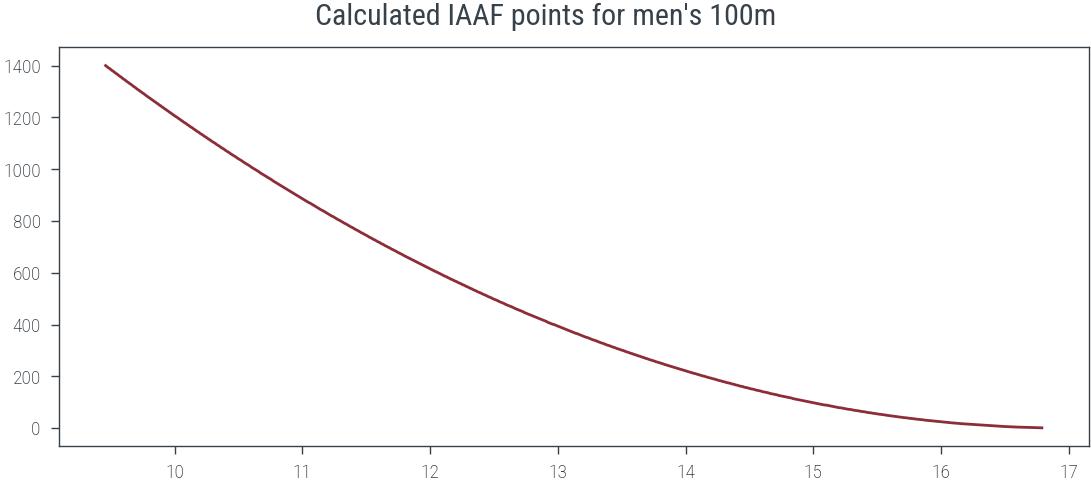

In [16]:
fig, ax = plt.subplots()

marks = iaaf_100m_points['mark'].to_list()
points = [score_from_mark("men", "100m", mark, iaaf_coefficients) for mark in marks]

ax.plot(marks, points, '-', color=rgb.tue_red)
fig.suptitle("Calculated IAAF points for men's 100m")

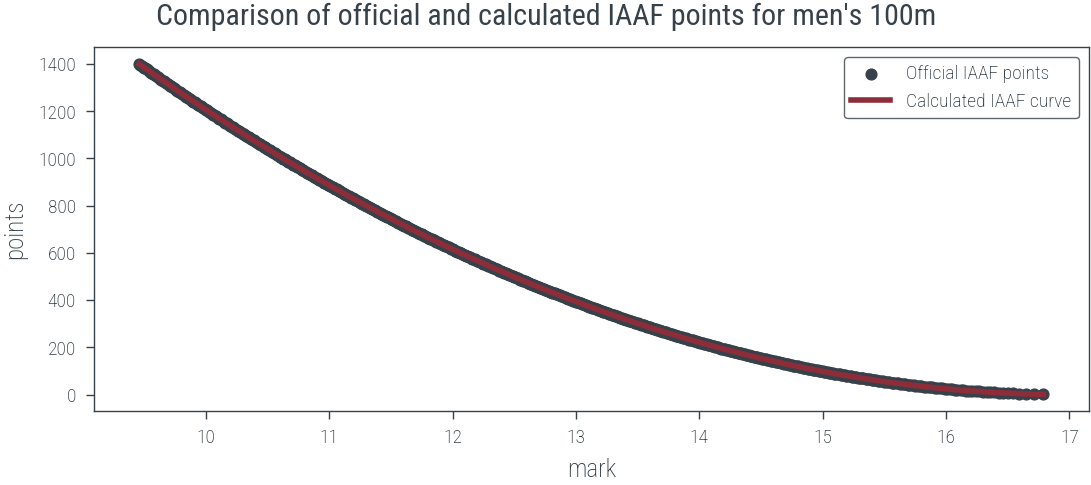

In [34]:
fig, ax = plt.subplots()

discipline = '100m'
gender = 'men'

df = iaaf_points[
    (iaaf_points['event'] == discipline) &
    (iaaf_points['gender'] == gender)
]

# Sort by mark (VERY important!)
df = df.sort_values("mark")

# Official points
ax.scatter(
    df['mark'],
    df['points'],
    color=rgb.tue_dark,
    label='Official IAAF points',
    s=15
)

# Smooth x-values for a clean curve
import numpy as np
x_curve = np.linspace(df['mark'].min(), df['mark'].max(), 400)
y_curve = [score_from_mark(gender, discipline, x, iaaf_coefficients) for x in x_curve]

# Regression curve
ax.plot(
    x_curve,
    y_curve,
    color=rgb.tue_red,
    label='Calculated IAAF curve',
    linewidth=2
)

fig.suptitle(f"Comparison of official and calculated IAAF points for {gender}'s {discipline}")
ax.set_xlabel("mark")
ax.set_ylabel("points")
ax.legend()



In [3]:
iaaf_coefficients.index.tolist()


['TJ',
 'Road 20kmW',
 'Road HM',
 'Hept. sh',
 '5000m',
 '300m',
 '200m',
 '55mH',
 '60mH',
 '4x400m',
 '50mH',
 '400m',
 'Mile sh',
 '600m',
 '10000m',
 '20,000mW',
 '3000m sh',
 '800m sh',
 'Road 3kmW',
 '5000mW',
 '4x200m sh',
 '50m',
 '500m',
 '15,000mW',
 'Road 10 Miles',
 '100m',
 '4x100m',
 'Road 15 km',
 '500m sh',
 '110mH',
 '10,000mW',
 '35,000mW',
 'Road 100 km',
 '400mH',
 'HJ',
 '300m sh',
 '4x400mix',
 'Road 30kmW',
 '2 Miles',
 '2000m SC',
 'PV',
 '400m sh',
 'HT',
 '3000m SC',
 '30,000mW',
 '1500m',
 '4x400mix sh',
 'JT',
 'Road 50kmW',
 'Road 30 km',
 '55m',
 '4x200m',
 '1500m sh',
 '3000m',
 'LJ',
 'Road 5kmW',
 'Road 5 km',
 '3000mW',
 'Road 15kmW',
 '50,000mW',
 '60m',
 '1000m sh',
 'Road 35kmW',
 '800m',
 '1000m',
 'Road 10kmW',
 'DT',
 '4x400m sh',
 'Dec.',
 'Road 20 km',
 '200m sh',
 'Road Marathon',
 '2000m',
 '5000m sh',
 'Mile',
 '2000m sh',
 'SP',
 'Road 10 km',
 'Road 25 km',
 '600m sh',
 '2 Miles sh',
 'Road Mile',
 'Hept.',
 'Pent. sh',
 '100mH']

In [4]:
from pathlib import Path
import sys
sys.path.append(str(Path.cwd().parent.parent / "data_csv"))
import util

In [5]:
disciplines = set()
for value in util.MEASUREMENT_TYPE.values():
    disciplines.update(value)

disciplines

{'10 000 m',
 '10 000 m Gehen',
 '10 km',
 '100 km',
 '100 m',
 '100 m Huerden',
 '1000 m',
 '110 m Huerden',
 '1500 m',
 '1500 m Hindernis',
 '200 m',
 '2000 m Hindernis',
 '300 m',
 '3000 m',
 '3000 m Gehen',
 '3000 m Hindernis',
 '400 m',
 '400 m Huerden',
 '5 km',
 '50 km Gehen',
 '5000 m',
 '800 m',
 'Diskuswurf',
 'Dreisprung',
 'Halbmarathon',
 'Hammerwurf',
 'Hochsprung',
 'Kugelstoss',
 'Marathon',
 'Siebenkampf',
 'Speerwurf',
 'Stabhochsprung',
 'Weitsprung',
 'Zehnkampf'}

In [6]:

events = set(EVENT_TO_DISCIPLINE.values())
len(events)

34

In [7]:
print(events.difference(disciplines))
print(disciplines.difference(events))

set()
set()
